# Capítulo 7 — Processos de Precipitação: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | curvas de Köhler: ativação, $r^*$, $S^*$ | NumPy |
| 2 | modelo de parcela com aerossol: ativação vs. updraft | `pyrcel` |
| 3 | corrida difusão × coleta: o gargalo e a avalanche | `scipy.solve_ivp` |
| 4 | Marshall–Palmer: momentos, $R$, $Z$ e a relação $Z$–$R$ | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap07_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

sigma_w, rho_L, Rv = 0.0761, 1000.0, 461.0   # N/m, kg/m3, J/kg/K
T0 = 283.15
A_K = 2*sigma_w/(rho_L*Rv*T0)                 # m — constante de Kelvin
print(f'A de Kelvin a 10 °C: {A_K*1e9:.2f} nm  (~1,2e-3 µm·K/T do livro)')

A de Kelvin a 10 °C: 1.17 nm  (~1,2e-3 µm·K/T do livro)


## Caso 1 — Curvas de Köhler: quem vira gota de nuvem

$$S(r) = 1 + \frac{A}{r} - \frac{\kappa\,r_d^3}{r^3}$$

Curvatura (Kelvin) empurra para cima; soluto (Raoult, parametrizado por $\kappa$) puxa para baixo. O máximo é o portão da ativação: $r^* = \sqrt{3\kappa r_d^3/A}$.

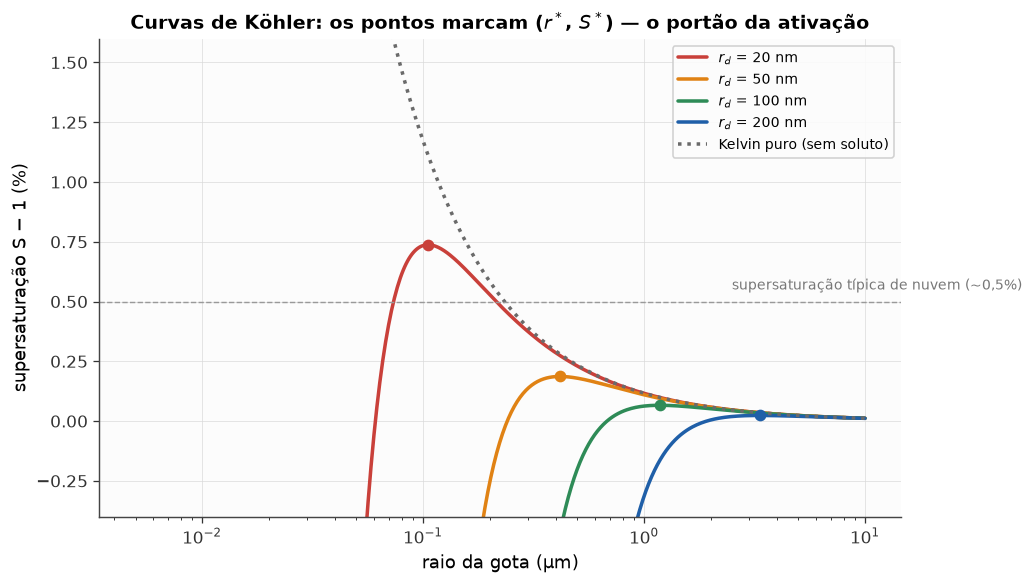

Núcleo maior → ativa com S menor. Sem núcleo nenhum (curva cinza),
precisaríamos de S de dezenas de % — por isso ar puro não faz nuvem.


In [2]:
kappa = 0.54                     # sulfato de amônio
r = np.logspace(-8.3, -5, 500)   # 5 nm a 10 µm

fig, ax = plt.subplots(figsize=(9, 5.4))
for rd_nm, cor in [(20, CORES['vermelho']), (50, CORES['laranja']),
                    (100, CORES['verde']), (200, CORES['azul'])]:
    rd = rd_nm*1e-9
    S = 1 + A_K/r - kappa*rd**3/r**3
    ax.semilogx(r*1e6, 100*(S - 1), color=cor, label=f'$r_d$ = {rd_nm} nm')
    rstar = np.sqrt(3*kappa*rd**3/A_K)
    Sstar = 1 + np.sqrt(4*A_K**3/(27*kappa*rd**3))
    ax.scatter([rstar*1e6], [100*(Sstar-1)], color=cor, zorder=5, s=40)
ax.semilogx(r*1e6, 100*(np.exp(A_K/r) - 1), ':', color=CORES['cinza'],
            label='Kelvin puro (sem soluto)')
ax.axhline(0.5, color='#999999', lw=0.9, ls='--')
ax.text(2.5, 0.55, 'supersaturação típica de nuvem (~0,5%)', fontsize=8.5,
        color='#777777')
ax.set(xlabel='raio da gota (µm)', ylabel='supersaturação S − 1 (%)',
       ylim=(-0.4, 1.6),
       title='Curvas de Köhler: os pontos marcam ($r^*$, $S^*$) — o portão da ativação')
ax.legend(fontsize=9)
plt.show()
print('Núcleo maior → ativa com S menor. Sem núcleo nenhum (curva cinza),\n'
      'precisaríamos de S de dezenas de % — por isso ar puro não faz nuvem.')

## Caso 2 — `pyrcel`: um modelo de pesquisa de ativação de aerossol

O [`pyrcel`](https://pyrcel.readthedocs.io) (D. Rothenberg) integra a subida de uma parcela com um espectro de aerossol dividido em bins, resolvendo supersaturação e crescimento de cada bin. Pergunta: **que fração do aerossol vira gota de nuvem, e como isso depende da velocidade de subida $W$?**

W =  0.2 m/s: S_max = 0.123% | ativados: 36%


W =  0.5 m/s: S_max = 0.199% | ativados: 53%


W =  1.0 m/s: S_max = 0.286% | ativados: 67%


W =  2.0 m/s: S_max = 0.415% | ativados: 79%


W =  5.0 m/s: S_max = 0.698% | ativados: 90%


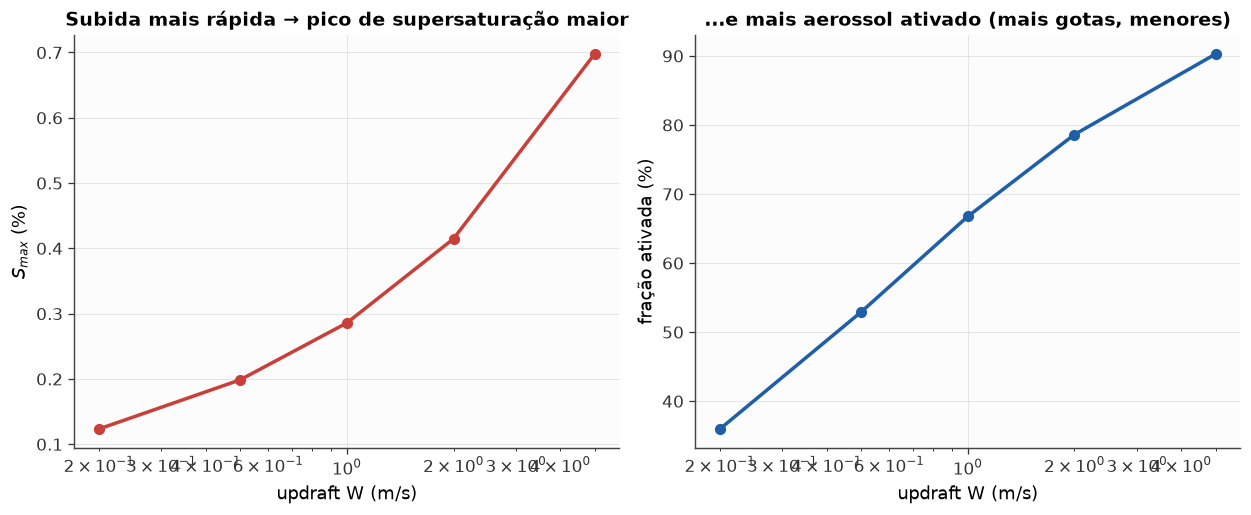

In [3]:
import pyrcel as pm

aerossol = pm.AerosolSpecies('sulfato',
                             pm.Lognorm(mu=0.05, sigma=2.0, N=850.0),
                             kappa=kappa, bins=120)

Ws = [0.2, 0.5, 1.0, 2.0, 5.0]
Smax_list, frac_list = [], []
for W in Ws:
    model = pm.ParcelModel([aerossol], W, T0, -0.02, 85000.0)
    out = model.run(t_end=600.0/W, output_dt=1.0)
    s = out.summary
    Smax_list.append(100*s['S_max'])
    frac_list.append(100*s['total_act_frac'])
    print(f'W = {W:4.1f} m/s: S_max = {100*s["S_max"]:.3f}% | '
          f'ativados: {100*s["total_act_frac"]:.0f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
ax1.semilogx(Ws, Smax_list, 'o-', color=CORES['vermelho'])
ax1.set(xlabel='updraft W (m/s)', ylabel='$S_{max}$ (%)',
        title='Subida mais rápida → pico de supersaturação maior')
ax2.semilogx(Ws, frac_list, 'o-', color=CORES['azul'])
ax2.set(xlabel='updraft W (m/s)', ylabel='fração ativada (%)',
        title='...e mais aerossol ativado (mais gotas, menores)')
fig.tight_layout(); plt.show()

**Discussão.** Termais fracas ativam só os núcleos grandes; correntes de tempestade ativam quase tudo. É essa competição que fixa o número de gotas da nuvem — e é este mesmo tipo de módulo que roda dentro dos modelos de clima para o efeito indireto do aerossol (Cap. 21).

## Caso 3 — A corrida: difusão (√t) × coleta (avalanche)

$$\underbrace{\frac{dr}{dt} = \frac{C}{r}}_{\text{difusão}}\qquad
\underbrace{\frac{dr}{dt} = \frac{E\,\bar{L}\,w_T(r)}{4\rho_L}}_{\text{coleta}},\qquad w_T = k_1 r^2\ (\text{Stokes, } r<40\,\mu\text{m})$$

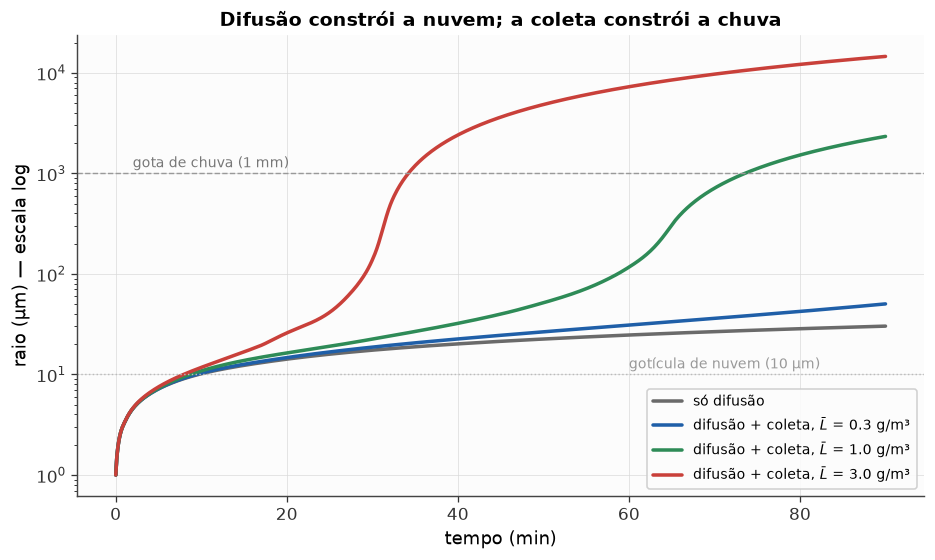

In [4]:
C_dif = 8.5e-14      # m²/s — difusão com S−1 ≈ 0,5%
k1 = 1.19e8          # 1/(m s) — Stokes
E_col = 0.6

def wT(r):
    return np.minimum(k1*r**2, 9.0)      # satura em ~9 m/s (gotas grandes)

def cresce(t, y, L_gm3):
    r = y[0]
    return [C_dif/r + E_col*(L_gm3*1e-3)*wT(r)/(4*rho_L)]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
t_span = np.linspace(1, 90*60, 800)
for L, cor in [(0.0, CORES['cinza']), (0.3, CORES['azul']),
               (1.0, CORES['verde']), (3.0, CORES['vermelho'])]:
    sol = solve_ivp(cresce, [1, 90*60], [1e-6], args=(L,), t_eval=t_span,
                    rtol=1e-8)
    rotulo = 'só difusão' if L == 0 else f'difusão + coleta, $\\bar L$ = {L} g/m³'
    ax.semilogy(sol.t/60, sol.y[0]*1e6, color=cor, label=rotulo)
ax.axhline(1000, color='#999999', ls='--', lw=0.9)
ax.text(2, 1150, 'gota de chuva (1 mm)', fontsize=8.5, color='#777777')
ax.axhline(10, color='#bbbbbb', ls=':', lw=0.9)
ax.text(60, 11.5, 'gotícula de nuvem (10 µm)', fontsize=8.5, color='#999999')
ax.set(xlabel='tempo (min)', ylabel='raio (µm) — escala log',
       title='Difusão constrói a nuvem; a coleta constrói a chuva')
ax.legend(fontsize=9, loc='lower right')
plt.show()

## Caso 4 — Marshall–Palmer: da estatística das gotas ao radar

$$N(D) = N_0\,e^{-\Lambda D},\qquad N_0 = 8\times10^3\ \mathrm{m^{-3}\,mm^{-1}},\quad \Lambda = 4{,}1\,R^{-0{,}21}\ \mathrm{mm^{-1}}$$

Os momentos da distribuição são as grandezas que medimos: massa ($\propto D^3$), taxa de chuva ($\propto D^3 w_T$) e refletividade de radar ($Z \propto D^6$ — dominada pelas raras gotas grandes!).

R nominal |  Λ (1/mm) | água (g/m³) | R recalc. | Z (dBZ)
        1 |      4.10 |        0.09 |      1.2  |   24.7
       10 |      2.53 |        0.62 |     11.1  |   39.4
       50 |      1.80 |        2.37 |     53.5  |   49.5


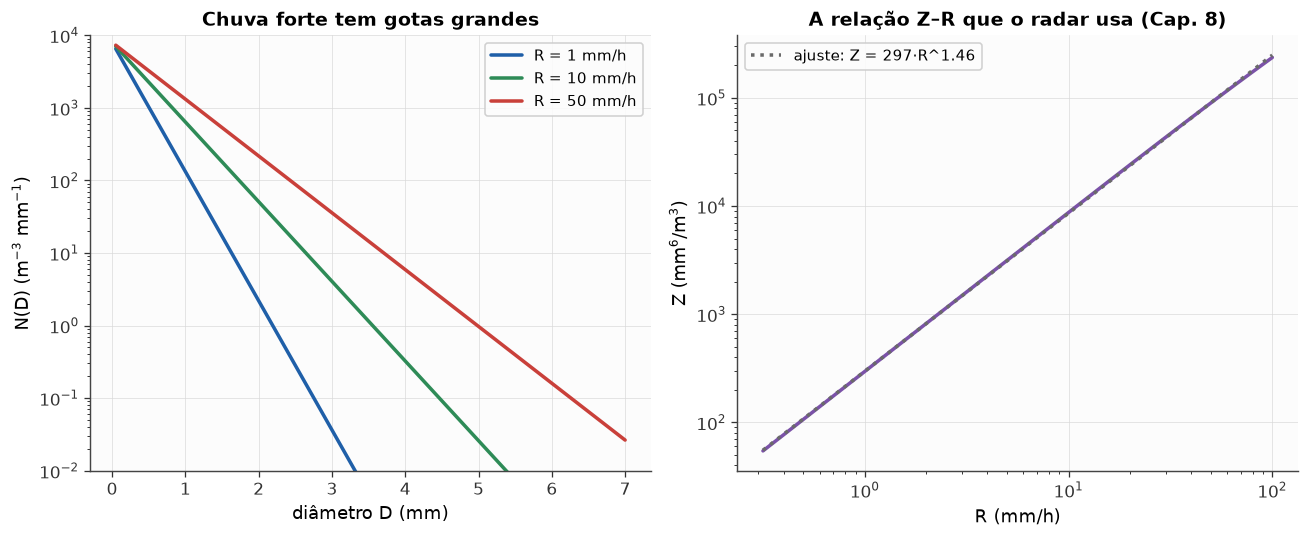

In [5]:
N0 = 8.0e3                       # m-3 mm-1
D = np.linspace(0.05, 7, 800)    # mm
wT_D = 3.78*D**0.67              # m/s (gotas de chuva)

def momentos(R_mmh):
    lam = 4.1*R_mmh**(-0.21)
    N = N0*np.exp(-lam*D)                       # m-3 mm-1
    M = np.trapezoid(np.pi/6*rho_L*(D*1e-3)**3*N, D)*1e3      # g/m3
    R_calc = np.trapezoid(np.pi/6*(D*1e-3)**3*N*wT_D, D)*3.6e6  # mm/h
    Z = np.trapezoid(N*D**6, D)                 # mm6/m3
    return lam, N, M, R_calc, Z

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))
Rs = np.array([1.0, 10.0, 50.0])
cores_R = [CORES['azul'], CORES['verde'], CORES['vermelho']]
print('R nominal |  Λ (1/mm) | água (g/m³) | R recalc. | Z (dBZ)')
for R_n, cor in zip(Rs, cores_R):
    lam, N, M, R_c, Z = momentos(R_n)
    ax1.semilogy(D, N, color=cor, label=f'R = {R_n:.0f} mm/h')
    print(f'{R_n:9.0f} | {lam:9.2f} | {M:11.2f} | {R_c:8.1f}  | {10*np.log10(Z):6.1f}')
ax1.set(xlabel='diâmetro D (mm)', ylabel='N(D) (m$^{-3}$ mm$^{-1}$)',
        ylim=(1e-2, 1e4), title='Chuva forte tem gotas grandes')
ax1.legend()

R_fino = np.logspace(-0.5, 2, 60)
Z_fino = np.array([momentos(R)[4] for R in R_fino])
coef = np.polyfit(np.log(R_fino), np.log(Z_fino), 1)
ax2.loglog(R_fino, Z_fino, color=CORES['roxo'])
ax2.loglog(R_fino, np.exp(coef[1])*R_fino**coef[0], ':', color=CORES['cinza'],
           label=f'ajuste: Z = {np.exp(coef[1]):.0f}·R^{coef[0]:.2f}')
ax2.set(xlabel='R (mm/h)', ylabel='Z (mm$^6$/m$^3$)',
        title='A relação Z–R que o radar usa (Cap. 8)')
ax2.legend()
fig.tight_layout(); plt.show()

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap07_solucoes.ipynb`**.

**N1** — Varra $\kappa$ de 0,1 (poeira pouco higroscópica) a 1,3 (sal marinho) e trace $S^*(r_d)$ para cada; confirme com a fórmula do T2.

**N2** — Com o `pyrcel` (Caso 2), duplique o número de aerossol ($N = 1700$ cm⁻³, ar poluído) e compare $S_{max}$ e o **número absoluto** de gotas ativadas com o caso limpo. O que acontece com o tamanho médio das gotas?

**N3** — No Caso 3, identifique numericamente o raio de *crossover* em que a taxa de coleta supera a de difusão, para cada $\bar L$; trace $r_{cross}(\bar L)$.

**N4** — Ainda com Marshall–Palmer: calcule o diâmetro mediano por massa $D_m$ numericamente e compare com $4/\Lambda$ (T5); verifique quanto do $Z$ vem das gotas com $D > D_m$.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*